 #### ***E-Commerce | Sales| Customer Segmentation | Top Down products| Ranking Analysis | Cumulative Analysis | Dimension Analysis | Magnitude  & Proportional Analysis | Behavioral Analysis | Csutomer Lifetime Analysis | ASP | AOV | AMP Analysis
 
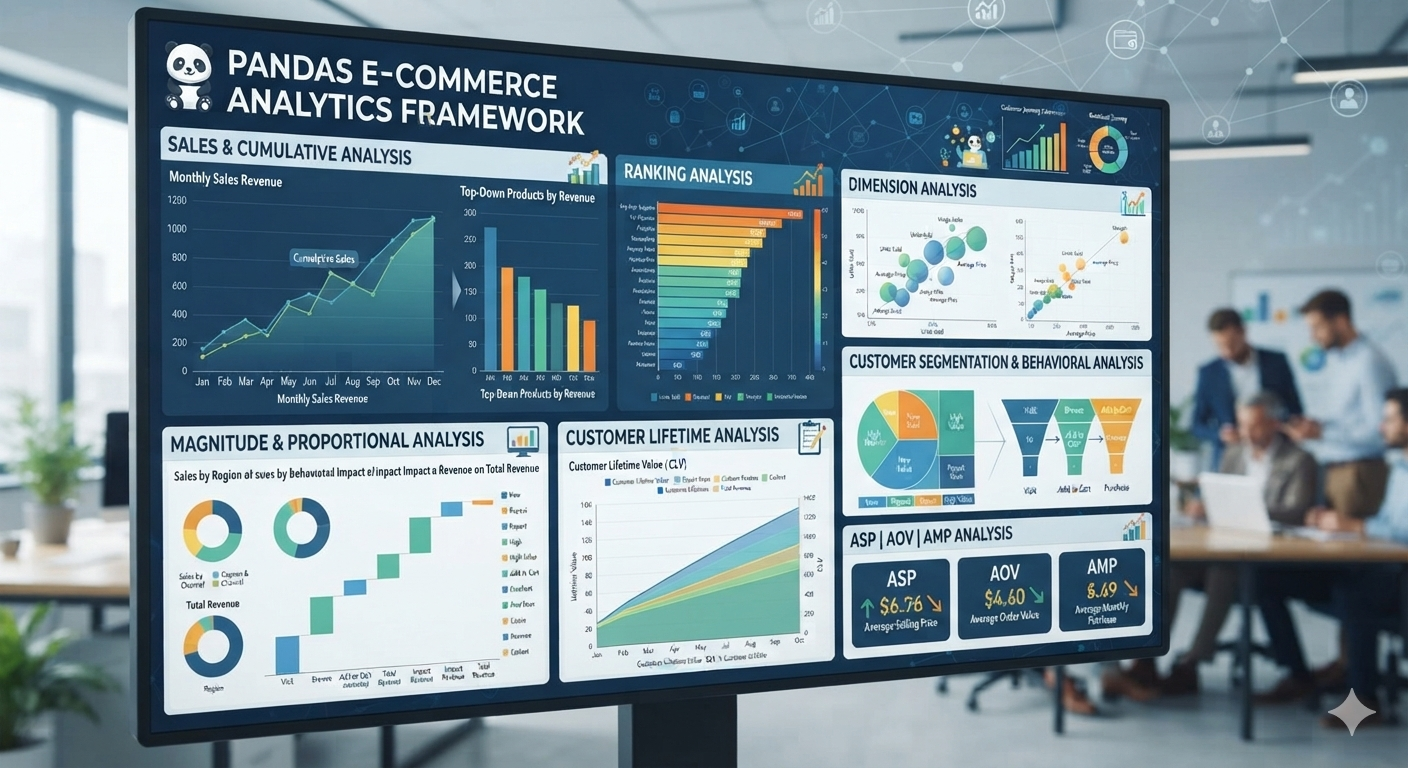
 
 
 
 
 
 ***

In [566]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [567]:
current_date = pd.Timestamp.today()

current_date

Timestamp('2026-10-09 05:00:20.457350')

In [568]:
# importing first file ---- customers

df = pd.read_csv(r"C:\Users\hp\Downloads\sql-data-analytics-project\flat-files\dim_customers.csv")
df

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06
...,...,...,...,...,...,...,...,...,...,...
18479,18480,29479,AW00029479,Tommy,Tang,France,Married,NaN,1969-06-30,2026-01-25
18480,18481,29480,AW00029480,Nina,Raji,United Kingdom,Single,NaN,1977-05-06,2026-01-25
18481,18482,29481,AW00029481,Ivan,Suri,Germany,Single,NaN,1965-07-04,2026-01-25
18482,18483,29482,AW00029482,Clayton,Zhang,France,Married,NaN,1964-09-01,2026-01-25


In [390]:
df.columns

Index(['customer_key', 'customer_id', 'customer_number', 'first_name',
       'last_name', 'country', 'marital_status', 'gender', 'birthdate',
       'create_date'],
      dtype='object')

In [391]:
df.shape

(18484, 10)

In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18484 entries, 0 to 18483
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_key     18484 non-null  int64 
 1   customer_id      18484 non-null  int64 
 2   customer_number  18484 non-null  object
 3   first_name       18484 non-null  object
 4   last_name        18484 non-null  object
 5   country          18147 non-null  object
 6   marital_status   18484 non-null  object
 7   gender           18469 non-null  object
 8   birthdate        18467 non-null  object
 9   create_date      18484 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.4+ MB


In [393]:
df.isnull().sum()

customer_key         0
customer_id          0
customer_number      0
first_name           0
last_name            0
country            337
marital_status       0
gender              15
birthdate           17
create_date          0
dtype: int64

In [394]:
df.isnull().sum().sum()

np.int64(369)

In [395]:
df.isnull().sum()[df.isnull().sum() >0]

country      337
gender        15
birthdate     17
dtype: int64

In [396]:
df_nullrecords = df[df.isnull().any(axis = 1)]

df_nullrecords

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
257,258,11257,AW00011257,Jacqueline,Powell,United States,Single,Female,NaN,2025-10-08
410,411,11410,AW00011410,Maurice,Goel,France,Married,Male,NaN,2025-10-08
551,552,11551,AW00011551,Shannon,Alvarez,France,Single,Male,NaN,2025-10-08
562,563,11562,AW00011562,Jarrod,Gonzalez,Germany,Married,Male,NaN,2025-10-08
581,582,11581,AW00011581,Cindy,Jordan,France,Married,Female,NaN,2025-10-08
...,...,...,...,...,...,...,...,...,...,...
18479,18480,29479,AW00029479,Tommy,Tang,France,Married,NaN,1969-06-30,2026-01-25
18480,18481,29480,AW00029480,Nina,Raji,United Kingdom,Single,NaN,1977-05-06,2026-01-25
18481,18482,29481,AW00029481,Ivan,Suri,Germany,Single,NaN,1965-07-04,2026-01-25
18482,18483,29482,AW00029482,Clayton,Zhang,France,Married,NaN,1964-09-01,2026-01-25


In [397]:
df_nullrecords.iloc[:25]

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
257,258,11257,AW00011257,Jacqueline,Powell,United States,Single,Female,NaN,2025-10-08
410,411,11410,AW00011410,Maurice,Goel,France,Married,Male,NaN,2025-10-08
551,552,11551,AW00011551,Shannon,Alvarez,France,Single,Male,NaN,2025-10-08
562,563,11562,AW00011562,Jarrod,Gonzalez,Germany,Married,Male,NaN,2025-10-08
581,582,11581,AW00011581,Cindy,Jordan,France,Married,Female,NaN,2025-10-08
775,776,11775,AW00011775,Sierra,Roberts,United States,Single,Female,NaN,2025-10-08
912,913,11912,AW00011912,Rachael,Sai,Australia,Single,Female,NaN,2025-10-08
915,916,11915,AW00011915,Philip,Carlson,Australia,Single,Male,NaN,2025-10-08
1123,1124,12123,AW00012123,Wesley,Liang,United Kingdom,Married,Male,NaN,2025-10-08
1145,1146,12145,AW00012145,Brandon,Butler,United States,Married,NaN,1976-09-30,2025-10-08


In [398]:
df.dtypes

customer_key        int64
customer_id         int64
customer_number    object
first_name         object
last_name          object
country            object
marital_status     object
gender             object
birthdate          object
create_date        object
dtype: object

In [399]:
df.head(2)

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06


In [400]:
df.head()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06


In [401]:
# changing the datatype 

df['birthdate'] = pd.to_datetime(df['birthdate'], errors = 'coerce')

In [402]:
# checking  datatype after changing

df.dtypes

customer_key                int64
customer_id                 int64
customer_number            object
first_name                 object
last_name                  object
country                    object
marital_status             object
gender                     object
birthdate          datetime64[ns]
create_date                object
dtype: object

In [403]:
# # changing the datatype 
df['create_date'] = pd.to_datetime(df['create_date'], errors = 'coerce')

In [404]:
df.dtypes

customer_key                int64
customer_id                 int64
customer_number            object
first_name                 object
last_name                  object
country                    object
marital_status             object
gender                     object
birthdate          datetime64[ns]
create_date        datetime64[ns]
dtype: object

In [405]:
df['country'].unique()

array(['Australia', 'United States', 'Canada', 'Germany',
       'United Kingdom', 'France', nan], dtype=object)

In [406]:
# importing second file ---- products

df1 = pd.read_csv(r"C:\Users\hp\Downloads\sql-data-analytics-project\flat-files\dim_products.csv")
df1

,product_key,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,1,210,FR-R92B-58,HL Road Frame - Black- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
1,2,211,FR-R92R-58,HL Road Frame - Red- 58,CO_RF,Components,Road Frames,Yes,0,Road,2003-07-01
2,3,348,BK-M82B-38,Mountain-100 Black- 38,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
3,4,349,BK-M82B-42,Mountain-100 Black- 42,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
4,5,350,BK-M82B-44,Mountain-100 Black- 44,BI_MB,Bikes,Mountain Bikes,Yes,1898,Mountain,2011-07-01
...,...,...,...,...,...,...,...,...,...,...,...
290,291,530,TT-T092,Touring Tire Tube,AC_TT,Accessories,Tires and Tubes,Yes,2,Touring,2013-07-01
291,292,473,VE-C304-L,Classic Vest- L,CL_VE,Clothing,Vests,No,24,Other Sales,2013-07-01
292,293,472,VE-C304-M,Classic Vest- M,CL_VE,Clothing,Vests,No,24,Other Sales,2013-07-01
293,294,471,VE-C304-S,Classic Vest- S,CL_VE,Clothing,Vests,No,24,Other Sales,2013-07-01


In [407]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_key     295 non-null    int64 
 1   product_id      295 non-null    int64 
 2   product_number  295 non-null    object
 3   product_name    295 non-null    object
 4   category_id     295 non-null    object
 5   category        288 non-null    object
 6   subcategory     288 non-null    object
 7   maintenance     288 non-null    object
 8   cost            295 non-null    int64 
 9   product_line    278 non-null    object
 10  start_date      295 non-null    object
dtypes: int64(3), object(8)
memory usage: 25.5+ KB


In [408]:
# changing the datatype

df1['start_date'] = pd.to_datetime(df1['start_date'], errors = 'coerce')

df1.dtypes

product_key                int64
product_id                 int64
product_number            object
product_name              object
category_id               object
category                  object
subcategory               object
maintenance               object
cost                       int64
product_line              object
start_date        datetime64[ns]
dtype: object

In [409]:
# examine null value in any column

df1.isnull().sum()

product_key        0
product_id         0
product_number     0
product_name       0
category_id        0
category           7
subcategory        7
maintenance        7
cost               0
product_line      17
start_date         0
dtype: int64

In [410]:
# Records conatining null values only
df1[df1.isnull().any(axis=1)]

,product_key,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
50,51,391,FK-1639,LL Fork,CO_FO,Components,Forks,Yes,66,NaN,2012-07-01
51,52,392,FK-5136,ML Fork,CO_FO,Components,Forks,Yes,78,NaN,2012-07-01
52,53,393,FK-9939,HL Fork,CO_FO,Components,Forks,Yes,102,NaN,2012-07-01
73,74,394,HS-0296,LL Headset,CO_HS,Components,Headsets,No,15,NaN,2012-07-01
74,75,395,HS-2451,ML Headset,CO_HS,Components,Headsets,No,45,NaN,2012-07-01
75,76,396,HS-3479,HL Headset,CO_HS,Components,Headsets,No,55,NaN,2012-07-01
100,101,601,BB-7421,LL Bottom Bracket,CO_BB,Components,Bottom Brackets,Yes,24,NaN,2013-07-01
101,102,602,BB-8107,ML Bottom Bracket,CO_BB,Components,Bottom Brackets,Yes,45,NaN,2013-07-01
102,103,603,BB-9108,HL Bottom Bracket,CO_BB,Components,Bottom Brackets,Yes,54,NaN,2013-07-01
166,167,559,CH-0234,Chain,CO_CH,Components,Chains,Yes,9,NaN,2013-07-01


### # examine unique values in each column

In [411]:

df1['product_line'].unique()

array(['Road', 'Mountain', nan, 'Touring', 'Other Sales'], dtype=object)

In [412]:
df1['category'].unique()

array(['Components', 'Bikes', 'Clothing', 'Accessories', nan],
      dtype=object)

In [413]:
df1['subcategory'].unique()

array(['Road Frames', 'Mountain Bikes', 'Road Bikes', 'Mountain Frames',
       'Socks', 'Forks', 'Wheels', 'Gloves', 'Headsets', 'Locks',
       'Lights', 'Panniers', 'Pumps', 'Bib-Shorts', 'Shorts', 'Tights',
       'Bottom Brackets', 'Bottles and Cages', 'Touring Bikes', 'Caps',
       'Chains', 'Cleaners', 'Cranksets', 'Brakes', 'Derailleurs',
       'Fenders', 'Touring Frames', 'Handlebars', 'Helmets',
       'Hydration Packs', 'Jerseys', nan, 'Tires and Tubes', 'Bike Racks',
       'Saddles', 'Bike Stands', 'Vests'], dtype=object)

In [414]:
df1['maintenance'].unique()

array(['Yes', 'No', nan], dtype=object)

In [415]:
df1_subset = df1.loc[:295,['category','subcategory','product_line','maintenance']]
df1_subset

,category,subcategory,product_line,maintenance
0,Components,Road Frames,Road,Yes
1,Components,Road Frames,Road,Yes
2,Bikes,Mountain Bikes,Mountain,Yes
3,Bikes,Mountain Bikes,Mountain,Yes
4,Bikes,Mountain Bikes,Mountain,Yes
...,...,...,...,...
290,Accessories,Tires and Tubes,Touring,Yes
291,Clothing,Vests,Other Sales,No
292,Clothing,Vests,Other Sales,No
293,Clothing,Vests,Other Sales,No


In [416]:
# importing third file ---- fact 

dffs = pd.read_csv(r"C:\Users\hp\Downloads\sql-data-analytics-project\flat-files\fact_sales.csv")
dffs

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9
...,...,...,...,...,...,...,...,...,...
60393,SO54494,259,11279,2013-03-16,2013-03-23,2013-03-28,2,1,2
60394,SO54495,289,3750,2013-03-16,2013-03-23,2013-03-28,5,1,5
60395,SO54495,244,3750,2013-03-16,2013-03-23,2013-03-28,35,1,35
60396,SO54495,248,3750,2013-03-16,2013-03-23,2013-03-28,50,1,50


In [417]:
dffs.isnull().sum()

order_number      0
product_key       0
customer_key      0
order_date       19
shipping_date     0
due_date          0
sales_amount      0
quantity          0
price             0
dtype: int64

In [418]:
dffs.dtypes

order_number     object
product_key       int64
customer_key      int64
order_date       object
shipping_date    object
due_date         object
sales_amount      int64
quantity          int64
price             int64
dtype: object

In [419]:
col = ['order_date','shipping_date','due_date']

for eachrow in col:
    dffs[eachrow] = pd.to_datetime(dffs[eachrow], errors = 'coerce')
print('Datatypes succesfully changes')

Datatypes succesfully changes


In [420]:
dffs.dtypes

order_number             object
product_key               int64
customer_key              int64
order_date       datetime64[ns]
shipping_date    datetime64[ns]
due_date         datetime64[ns]
sales_amount              int64
quantity                  int64
price                     int64
dtype: object

## Dimension Analysis  - Products

In [421]:
df.head(3)


,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06


In [422]:
df['customer_id'].count()

np.int64(18484)

In [423]:
# making Age column to get customer age

df['Age'] = ( current_date - df['birthdate']).dt.days / 365.25


In [424]:
df['Age'] = df['Age'].round(0)

In [425]:
df.head()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06,55.0
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06,50.0
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06,56.0
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06,53.0
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06,47.0


In [426]:
df['marital_status'].value_counts()

marital_status
Married    10011
Single      8473
Name: count, dtype: int64

In [427]:
df['gender'].value_counts()

gender
Male      9341
Female    9128
Name: count, dtype: int64

In [428]:
df['country'].value_counts()

country
United States     7482
Australia         3591
United Kingdom    1913
France            1810
Germany           1780
Canada            1571
Name: count, dtype: int64

In [429]:
df.head()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06,55.0
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06,50.0
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06,56.0
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06,53.0
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06,47.0


In [430]:
# droping first_name and last_name 

### df.drop(columns = ['first_name','last_name'],axis = 1, inplace = True)

In [431]:
df.tail()

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
18479,18480,29479,AW00029479,Tommy,Tang,France,Married,NaN,1969-06-30,2026-01-25,57.0
18480,18481,29480,AW00029480,Nina,Raji,United Kingdom,Single,NaN,1977-05-06,2026-01-25,49.0
18481,18482,29481,AW00029481,Ivan,Suri,Germany,Single,NaN,1965-07-04,2026-01-25,61.0
18482,18483,29482,AW00029482,Clayton,Zhang,France,Married,NaN,1964-09-01,2026-01-25,62.0
18483,18484,29483,AW00029483,Marc,Navarro,France,Married,NaN,NaT,2026-01-27,NaN


In [432]:
df.head(6)

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06,55.0
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06,50.0
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06,56.0
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06,53.0
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06,47.0
5,6,11005,AW00011005,Julio,Ruiz,Australia,Single,Male,1976-08-01,2025-10-06,50.0


In [433]:
married_customers = df[df['marital_status'] == 'Married']

married_customers

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
0,1,11000,AW00011000,Jon,Yang,Australia,Married,Male,1971-10-06,2025-10-06,55.0
2,3,11002,AW00011002,Ruben,Torres,Australia,Married,Male,1971-02-09,2025-10-06,56.0
7,8,11007,AW00011007,Marco,Mehta,Australia,Married,Male,1969-11-06,2025-10-06,57.0
11,12,11011,AW00011011,Curtis,Lu,Australia,Married,Male,1969-05-03,2025-10-06,57.0
12,13,11012,AW00011012,Lauren,Walker,United States,Married,Female,1979-01-14,2025-10-06,48.0
...,...,...,...,...,...,...,...,...,...,...,...
18476,18477,29476,AW00029476,Elizabeth,Bradley,Germany,Married,NaN,1964-12-30,2026-01-25,62.0
18477,18478,29477,AW00029477,Neil,Ruiz,United Kingdom,Married,NaN,1965-01-02,2026-01-25,62.0
18479,18480,29479,AW00029479,Tommy,Tang,France,Married,NaN,1969-06-30,2026-01-25,57.0
18482,18483,29482,AW00029482,Clayton,Zhang,France,Married,NaN,1964-09-01,2026-01-25,62.0


In [434]:
single_customers = df[df['marital_status'] == 'Single']

single_customers.iloc[:10]

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
1,2,11001,AW00011001,Eugene,Huang,Australia,Single,Male,1976-05-10,2025-10-06,50.0
3,4,11003,AW00011003,Christy,Zhu,Australia,Single,Female,1973-08-14,2025-10-06,53.0
4,5,11004,AW00011004,Elizabeth,Johnson,Australia,Single,Female,1979-08-05,2025-10-06,47.0
5,6,11005,AW00011005,Julio,Ruiz,Australia,Single,Male,1976-08-01,2025-10-06,50.0
6,7,11006,AW00011006,Janet,Alvarez,Australia,Single,Female,1976-12-02,2025-10-06,50.0
8,9,11008,AW00011008,Rob,Verhoff,Australia,Single,Female,1975-07-04,2025-10-06,51.0
9,10,11009,AW00011009,Shannon,Carlson,Australia,Single,Male,1969-09-29,2025-10-06,57.0
10,11,11010,AW00011010,Jacquelyn,Suarez,Australia,Single,Female,1969-08-05,2025-10-06,57.0
14,15,11014,AW00011014,Sydney,Bennett,United States,Single,Female,1973-11-06,2025-10-06,53.0
15,16,11015,AW00011015,Chloe,Young,United States,Single,Female,1984-08-26,2025-10-06,42.0


In [435]:
married_customers.count()

customer_key       10011
customer_id        10011
customer_number    10011
first_name         10011
last_name          10011
country             9786
marital_status     10011
gender             10003
birthdate          10004
create_date        10011
Age                10004
dtype: int64

In [436]:
married_customers[married_customers['country'] == 'Germany'].count()

customer_key       865
customer_id        865
customer_number    865
first_name         865
last_name          865
country            865
marital_status     865
gender             863
birthdate          864
create_date        865
Age                864
dtype: int64

In [437]:
single_customers.count()

customer_key       8473
customer_id        8473
customer_number    8473
first_name         8473
last_name          8473
country            8361
marital_status     8473
gender             8466
birthdate          8463
create_date        8473
Age                8463
dtype: int64

###  MAGNITUDE & PROPORTIONAL ANALYSIS

In [438]:
joined_dffs_with_df = dffs.merge(df[['customer_key','country','gender','marital_status']],on='customer_key',how='left')

joined_dffs_with_df

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,country,gender,marital_status
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,Germany,Male,Single
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,Germany,Male,Single
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,Germany,Male,Single
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,Canada,Male,Single
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,Canada,Male,Single
...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO54494,259,11279,2013-03-16,2013-03-23,2013-03-28,2,1,2,Canada,Female,Single
60394,SO54495,289,3750,2013-03-16,2013-03-23,2013-03-28,5,1,5,United States,Male,Married
60395,SO54495,244,3750,2013-03-16,2013-03-23,2013-03-28,35,1,35,United States,Male,Married
60396,SO54495,248,3750,2013-03-16,2013-03-23,2013-03-28,50,1,50,United States,Male,Married


##### Revenue and averge revenue by country

In [553]:
Total_and_average_sales_by_country= joined_dffs_with_df.groupby(['country']).agg(
                        Total_sales = ('sales_amount',lambda x : round(x.sum()/1000000,2)),
                        Avg_sales = ('sales_amount',lambda x : round(x.mean(),2))
).reset_index().sort_values(['country','Total_sales'], ascending=[True,False])

Total_and_average_sales_by_country 

,country,Total_sales,Avg_sales
0,Australia,9.06,678.92
1,Canada,1.98,259.55
2,France,2.64,475.67
3,Germany,2.89,514.50
4,United Kingdom,3.39,491.08
5,United States,9.16,447.53


###### Creating Visuals for the above query

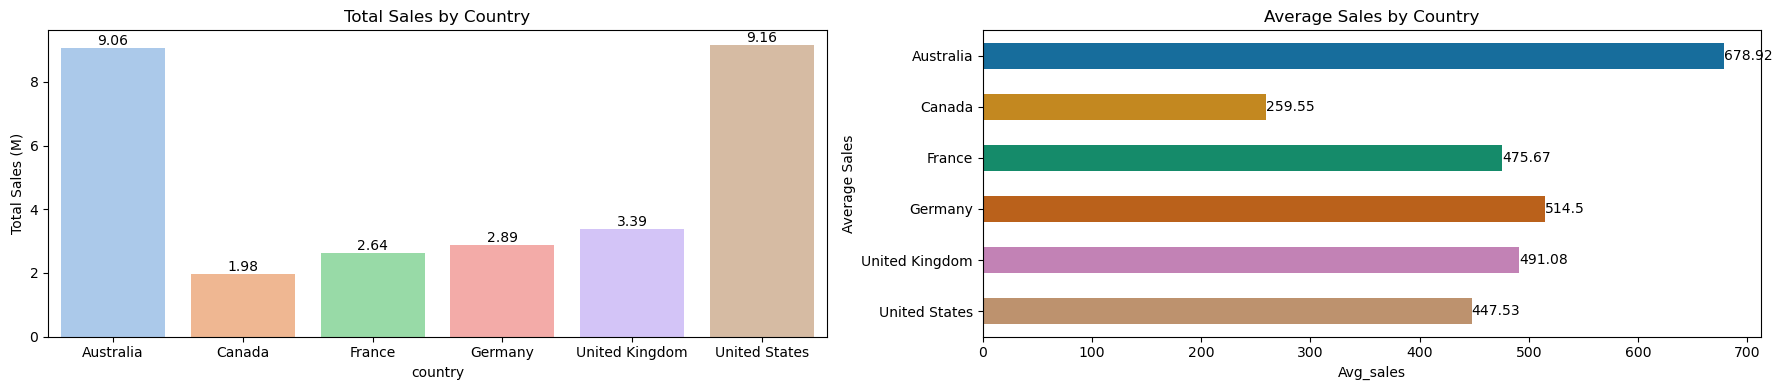

In [699]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

ax1 = sns.barplot(
    data=Total_and_average_sales_by_country,
    x='country',
    y='Total_sales',
    ax=axes[0],
    errorbar=None,
    palette = 'pastel',
    hue = "country",
    legend = False
)

ax2 = sns.barplot(
    data=Total_and_average_sales_by_country,
    x='Avg_sales',
    y='country',
    ax=axes[1],
    errorbar=None,
    hue = "country",
    palette = 'colorblind',
    width = 0.5
)

for i1 in ax1.containers:
    ax1.bar_label(i1)

for i2 in ax2.containers:
    ax2.bar_label(i2)
    
axes[0].set_title('Total Sales by Country')
axes[0].set_ylabel('Total Sales (M)')

axes[1].set_title('Average Sales by Country')
axes[1].set_ylabel('Average Sales')


plt.tight_layout()
plt.show()
fig.savefig('Avg and Total Sales by Country.png',dpi=300,bbox_inches='tight')

[<BarContainer object of 1 artists>, <BarContainer object of 1 artists>, <BarContainer object of 1 artists>]


#### Revenue Performance by Country and Gender

In [440]:
Total_and_average_sales_by_country_gender = joined_dffs_with_df.groupby(['country','gender']).agg(
                        Total_sales = ('sales_amount','sum'),
                        Avg_sales = ('sales_amount','mean')
).reset_index().sort_values(['country','Total_sales'], ascending=[True,False])

Total_and_average_sales_by_country_gender

,country,gender,Total_sales,Avg_sales
0,Australia,Female,4634558,693.277188
1,Australia,Male,4425614,664.506607
2,Canada,Female,1011343,277.232182
3,Canada,Male,966395,243.301863
5,France,Male,1365721,492.862144
4,France,Female,1271711,458.109150
6,Germany,Female,1536211,544.948918
7,Germany,Male,1344305,479.766238
9,United Kingdom,Male,1771689,506.341526
8,United Kingdom,Female,1610000,474.366529


#### Revenue Analysis Across Country, Gender & Marital Status

In [441]:
Total_and_average_sales_by_country_gender_marital_status = joined_dffs_with_df.groupby(['country','marital_status','gender']).agg(
                        Total_sales = ('sales_amount','sum'),
                        Avg_sales = ('sales_amount','mean')
).reset_index().sort_values(['country','gender'], ascending=[True,False])

Total_and_average_sales_by_country_gender_marital_status 

,country,marital_status,gender,Total_sales,Avg_sales
1,Australia,Married,Male,2265783,607.285714
3,Australia,Single,Male,2159831,737.395357
0,Australia,Married,Female,1953645,587.562406
2,Australia,Single,Female,2680913,797.890774
5,Canada,Married,Male,572272,217.098634
7,Canada,Single,Male,394123,295.002246
4,Canada,Married,Female,505846,256.124557
6,Canada,Single,Female,505497,302.150030
9,France,Married,Male,741731,548.212121
11,France,Single,Male,623990,440.049365


### Total Unique customers


In [442]:
df['customer_id'].nunique()

18484

### Oldest and youngest customers

In [443]:
df['Age'].max()

111.0

In [444]:
df[df['Age'] == df['Age'].max()]

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
1725,1726,12725,AW00012725,Gabrielle,James,Germany,Married,Female,1916-02-10,2025-10-12,111.0


In [445]:
df['Age'].min()

40.0

In [446]:
df[df['Age'] == df['Age'].min()]

,customer_key,customer_id,customer_number,first_name,last_name,country,marital_status,gender,birthdate,create_date,Age
132,133,11132,AW00011132,Melissa,Richardson,Canada,Single,Female,1986-04-25,2025-10-07,40.0
607,608,11607,AW00011607,Clinton,Moreno,France,Single,Male,1986-05-05,2025-10-08,40.0
904,905,11904,AW00011904,Kaylee,Cook,Australia,Single,Female,1986-05-05,2025-10-08,40.0
949,950,11949,AW00011949,Julia,Brooks,United States,Single,Female,1986-05-05,2025-10-08,40.0
1019,1020,12019,AW00012019,Gabrielle,Cox,United States,Single,Female,1986-05-13,2025-10-08,40.0
...,...,...,...,...,...,...,...,...,...,...,...
17334,17335,28334,AW00028334,Marco,Tanara,United States,Single,Female,1986-05-17,2026-01-25,40.0
17337,17338,28337,AW00028337,Melissa,Bennett,United States,Married,Female,1986-05-15,2026-01-25,40.0
17548,17549,28548,AW00028548,Krista,Ortega,Germany,Single,Female,1986-05-17,2026-01-25,40.0
17727,17728,28727,AW00028727,Brett,Madan,France,Single,Male,1986-05-01,2026-01-25,40.0


### count of customers who has minimum age 

##### One method

In [192]:
len(df[df['Age'] == df['Age'].min()])

86

##### Second method

In [193]:
df[df['Age'] == df['Age'].min()]['Age'].count()

np.int64(86)

##### Third method

In [183]:
df[df['Age'] == df['Age'].min()].shape

86

#### Demographic Customer Segmentation Analysis

##### customer who are married with age between 40 and 50

In [227]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Married')]['customer_key'].nunique()


2603

##### customer who are single with age between 40 and 50

In [228]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Single')]['customer_key'].nunique()


3498

##### male customer with age between 40 and 50

In [194]:
df[(df['Age'].between(40,50)) & (df['gender'] == 'Male')]['customer_key'].nunique()


3084

##### female customer with age between 40 and 50

In [195]:
df[(df['Age'].between(40,50)) & (df['gender'] == 'Female')]['customer_key'].nunique()


3014

##### male customer who are married with age between 40 and 50

In [196]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Married') & (df['gender'] == 'Male')]['customer_key'].nunique()


1373

##### male customer who are single with age between 40 and 50

In [197]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Single') & (df['gender'] == 'Male')]['customer_key'].nunique()


1711

##### Female customer who are married with age between 40 and 50

In [198]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Married') & (df['gender'] == 'Female')]['customer_key'].nunique()


1229

##### male customer who are single with age between 40 and 50

In [199]:
df[(df['Age'].between(40,50)) & (df['marital_status'] == 'Single') & (df['gender'] == 'Female')]['customer_key'].nunique()


1785

In [194]:
df.head()

,customer_key,customer_id,customer_number,full_name,gender,country,marital_status,Age,birthdate,create_date
0,1,11000,AW00011000,Jon Yang,Male,Australia,Married,55.0,1971-10-06,2025-10-06
1,2,11001,AW00011001,Eugene Huang,Male,Australia,Single,50.0,1976-05-10,2025-10-06
2,3,11002,AW00011002,Ruben Torres,Male,Australia,Married,56.0,1971-02-09,2025-10-06
3,4,11003,AW00011003,Christy Zhu,Female,Australia,Single,53.0,1973-08-14,2025-10-06
4,5,11004,AW00011004,Elizabeth Johnson,Female,Australia,Single,47.0,1979-08-05,2025-10-06


### Total revenue by category

In [157]:
Joined_dffs_and_df1 = dffs.merge(df1[['product_key','category','subcategory','cost']],on='product_key',how='left')
Joined_dffs_and_df1 

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,category,subcategory,cost
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,Accessories,Tires and Tubes,9
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,Accessories,Tires and Tubes,2
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,Accessories,Tires and Tubes,1
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,Accessories,Fenders,8
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,Clothing,Socks,3
...,...,...,...,...,...,...,...,...,...,...,...,...
60393,SO54494,259,11279,2013-03-16,2013-03-23,2013-03-28,2,1,2,Accessories,Tires and Tubes,1
60394,SO54495,289,3750,2013-03-16,2013-03-23,2013-03-28,5,1,5,Accessories,Tires and Tubes,2
60395,SO54495,244,3750,2013-03-16,2013-03-23,2013-03-28,35,1,35,Accessories,Helmets,13
60396,SO54495,248,3750,2013-03-16,2013-03-23,2013-03-28,50,1,50,Clothing,Jerseys,38


In [158]:
Total_revenue_by_product = Joined_dffs_and_df1.groupby(['category']).agg(Total_Revenue= ('sales_amount','sum')).reset_index().sort_values('Total_Revenue',ascending = False)

Total_revenue_by_product
    

,category,Total_Revenue
1,Bikes,28316272
0,Accessories,700262
2,Clothing,339716


### Total revenue by category with Subcategory

In [159]:


Total_Revenue_by_subcategory = Joined_dffs_and_df1.groupby(['category','subcategory']).agg(Total_Revenue_In_Millions = ('sales_amount','sum')).reset_index().sort_values('Total_Revenue_In_Millions',ascending = False)
Total_Revenue_by_subcategory

,category,subcategory,Total_Revenue_In_Millions
9,Bikes,Road Bikes,14519438
8,Bikes,Mountain Bikes,9952254
10,Bikes,Touring Bikes,3844580
7,Accessories,Tires and Tubes,244634
5,Accessories,Helmets,225435
13,Clothing,Jerseys,173084
14,Clothing,Shorts,71330
2,Accessories,Bottles and Cages,56993
4,Accessories,Fenders,46662
6,Accessories,Hydration Packs,40315


### Total revenue by category with Subcategory by adding column name as dictionary 

In [160]:


Total_Revenue_by_subcategory = Joined_dffs_and_df1.groupby(['category','subcategory']).agg(**{'Total_Revenue(In_Millions)' : ('sales_amount',lambda x: x.sum() / 10_00_000)}).reset_index().sort_values('Total_Revenue(In_Millions)',ascending = False)
Total_Revenue_by_subcategory

,category,subcategory,Total_Revenue(In_Millions)
9,Bikes,Road Bikes,14.519438
8,Bikes,Mountain Bikes,9.952254
10,Bikes,Touring Bikes,3.844580
7,Accessories,Tires and Tubes,0.244634
5,Accessories,Helmets,0.225435
13,Clothing,Jerseys,0.173084
14,Clothing,Shorts,0.071330
2,Accessories,Bottles and Cages,0.056993
4,Accessories,Fenders,0.046662
6,Accessories,Hydration Packs,0.040315


#### Contribution for each product

In [268]:
joined_dffs_df_df1.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,customer_number,country,full_name,gender,Age,marital_status,product_number,product_name,category,subcategory
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TI-M267,LL Mountain Tire,Accessories,Tires and Tubes
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TT-M928,Mountain Tire Tube,Accessories,Tires and Tubes
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,AW00016399,Germany,Arturo Xu,Male,53.0,Single,PK-7098,Patch Kit/8 Patches,Accessories,Tires and Tubes
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,AW00020280,Canada,Joshua Harris,Male,42.0,Single,FE-6654,Fender Set - Mountain,Accessories,Fenders
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,AW00020280,Canada,Joshua Harris,Male,42.0,Single,SO-R809-M,Racing Socks- M,Clothing,Socks


In [306]:
category_wise_total_sales = joined_dffs_df_df1.groupby('category').agg(Total_Sales = ('sales_amount','sum')).reset_index()

overall_sales = joined_dffs_df_df1['sales_amount'].sum()

category_wise_total_sales['contribution %'] = (category_wise_total_sales['Total_Sales'] / overall_sales * 100).round(2)

sorted_category_wise_total_sales= category_wise_total_sales.sort_values('contribution %',ascending = False)
sorted_category_wise_total_sales

,category,Total_Sales,contribution %
1,Bikes,28316272,96.46
0,Accessories,700262,2.39
2,Clothing,339716,1.16


In [323]:
def color_scheme(row):
    styles = []

    # Total Sales
    if row['Total_Sales'] > 10000000:
        styles.append('color: green; font-weight: bold')
    else:
        styles.append('color: purple; font-weight: 400')

    # Contribution %
    if row['contribution %'] > 70:
        styles.append('color: green; font-weight: bold')
    else:
        styles.append('color: red; font-weight: 400')

    return styles


sorted_category_wise_total_sales.style.apply(
    color_scheme,
    axis=1,
    subset=['Total_Sales', 'contribution %']
)

,category,Total_Sales,contribution %
1,Bikes,28316272,96.460000
0,Accessories,700262,2.390000
2,Clothing,339716,1.160000


In [316]:
def color_schme(row):
    if row > 70:
        return 'color : green; font-weight : bold'
    else:
        return 'color : red; font-weight : 400's

sorted_category_wise_total_sales.style.map(color_schme, subset=['contribution %'])


,category,Total_Sales,contribution %
1,Bikes,28316272,96.460000
0,Accessories,700262,2.390000
2,Clothing,339716,1.160000


##### Hence, Bikes contributes majority of sales across countries as this is not good for the business, need much more attention towards other category as well.

----------------------------------------------------------------------------------------------------------------------------------------------

##### Joined fact sales with customers

In [162]:
joined_dffs_df_df1 = dffs.merge(df[['customer_key','customer_number','country','full_name','gender','Age','marital_status']],
                    on='customer_key',how='left').merge(
                    df1[['product_key','product_number','product_name','category','subcategory']],
                    on='product_key',how='left')

joined_dffs_df_df1.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,customer_number,country,full_name,gender,Age,marital_status,product_number,product_name,category,subcategory
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TI-M267,LL Mountain Tire,Accessories,Tires and Tubes
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TT-M928,Mountain Tire Tube,Accessories,Tires and Tubes
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,AW00016399,Germany,Arturo Xu,Male,53.0,Single,PK-7098,Patch Kit/8 Patches,Accessories,Tires and Tubes
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,AW00020280,Canada,Joshua Harris,Male,42.0,Single,FE-6654,Fender Set - Mountain,Accessories,Fenders
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,AW00020280,Canada,Joshua Harris,Male,42.0,Single,SO-R809-M,Racing Socks- M,Clothing,Socks


#### Average cost by category

In [163]:
Average_cost_by_category = df1.groupby('category').agg(Average_Cost_each_Category = ('cost','mean')).reset_index()

Average_cost_by_category.index += 1 ### Reset index from 0 to 1

Average_cost_by_category

,category,Average_Cost_each_Category
1,Accessories,13.172414
2,Bikes,949.443299
3,Clothing,24.800000
4,Components,264.716535


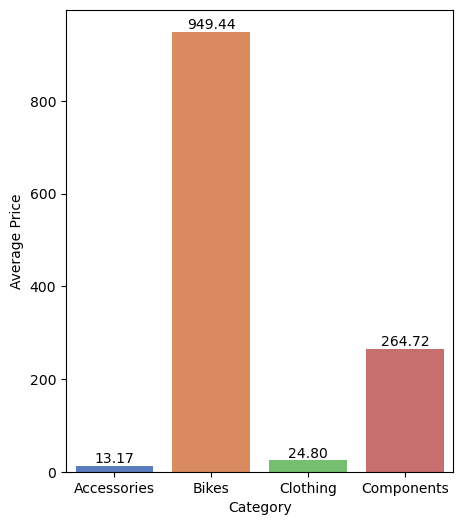

In [502]:
plt.figure(figsize=(5,6))


ax = sns.barplot(
    data = Average_cost_by_category,
    x = 'category',
    y = 'Average_Cost_each_Category',
    hue = 'category',
    palette = 'muted'
)

for i in ax.containers:
 ax.bar_label(i,fmt='%.2f')


plt.ylabel('Average Price')
plt.xlabel('Category')
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### RANKING ANALYSIS

#### Top 3 countries generating overall revenue

In [164]:
joined_dffs_with_df.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,country,gender,marital_status
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,Germany,Male,Single
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,Germany,Male,Single
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,Germany,Male,Single
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,Canada,Male,Single
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,Canada,Male,Single


In [165]:
Top_3_countries =  joined_dffs_with_df.groupby('country').agg(**{'Total Revenue':('sales_amount',lambda x : x.sum())}).reset_index().sort_values('Total Revenue', ascending=True)
a = Top_3_countries.nlargest(3,'Total Revenue')

In [166]:
a.reset_index(drop=True)
a.index = [1,2,3]
a

,country,Total Revenue
1,United States,9162327
2,Australia,9060172
3,United Kingdom,3391376


##### Top 5 Most Popular Products per Country by Volume

In [167]:
joined_dffs_df_df1.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,customer_number,country,full_name,gender,Age,marital_status,product_number,product_name,category,subcategory
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TI-M267,LL Mountain Tire,Accessories,Tires and Tubes
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,AW00016399,Germany,Arturo Xu,Male,53.0,Single,TT-M928,Mountain Tire Tube,Accessories,Tires and Tubes
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,AW00016399,Germany,Arturo Xu,Male,53.0,Single,PK-7098,Patch Kit/8 Patches,Accessories,Tires and Tubes
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,AW00020280,Canada,Joshua Harris,Male,42.0,Single,FE-6654,Fender Set - Mountain,Accessories,Fenders
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,AW00020280,Canada,Joshua Harris,Male,42.0,Single,SO-R809-M,Racing Socks- M,Clothing,Socks


In [650]:
## first group by the country and product name with total qty.

Top_5_Most_Popular_Products_per_Country_volume = joined_dffs_df_df1.groupby(['country','product_name']).agg(Total_Volume = ('quantity','sum')).reset_index().sort_values('Total_Volume',ascending=False)

Top_5_Most_Popular_Products_per_Country_volume


## now creating rank column in the Dataframe
Top_5_Most_Popular_Products_per_Country_volume['Rank'] = Top_5_Most_Popular_Products_per_Country_volume.groupby('country')['Total_Volume'].rank(method ='dense' , ascending=False)
Top_5_Most_Popular_Products_per_Country_volume

## now filter top 5 products in each countries

#@Top_5_Most_Popular_Products_per_Country_volume.drop('index')

df_top5 = Top_5_Most_Popular_Products_per_Country_volume [Top_5_Most_Popular_Products_per_Country_volume['Rank'] <=5].sort_values(['country','Rank'])


df_top5['Rank'] = df_top5['Rank'].astype('int')
df_top5

,country,product_name,Total_Volume,Rank
126,Australia,Water Bottle - 30 oz.,792,1
52,Australia,Patch Kit/8 Patches,667,2
23,Australia,Mountain Tire Tube,514,3
56,Australia,Road Tire Tube,511,4
55,Australia,Road Bottle Cage,509,5
153,Canada,Mountain Tire Tube,649,1
255,Canada,Water Bottle - 30 oz.,606,2
181,Canada,Patch Kit/8 Patches,506,3
136,Canada,Fender Set - Mountain,400,4
152,Canada,Mountain Bottle Cage,371,5


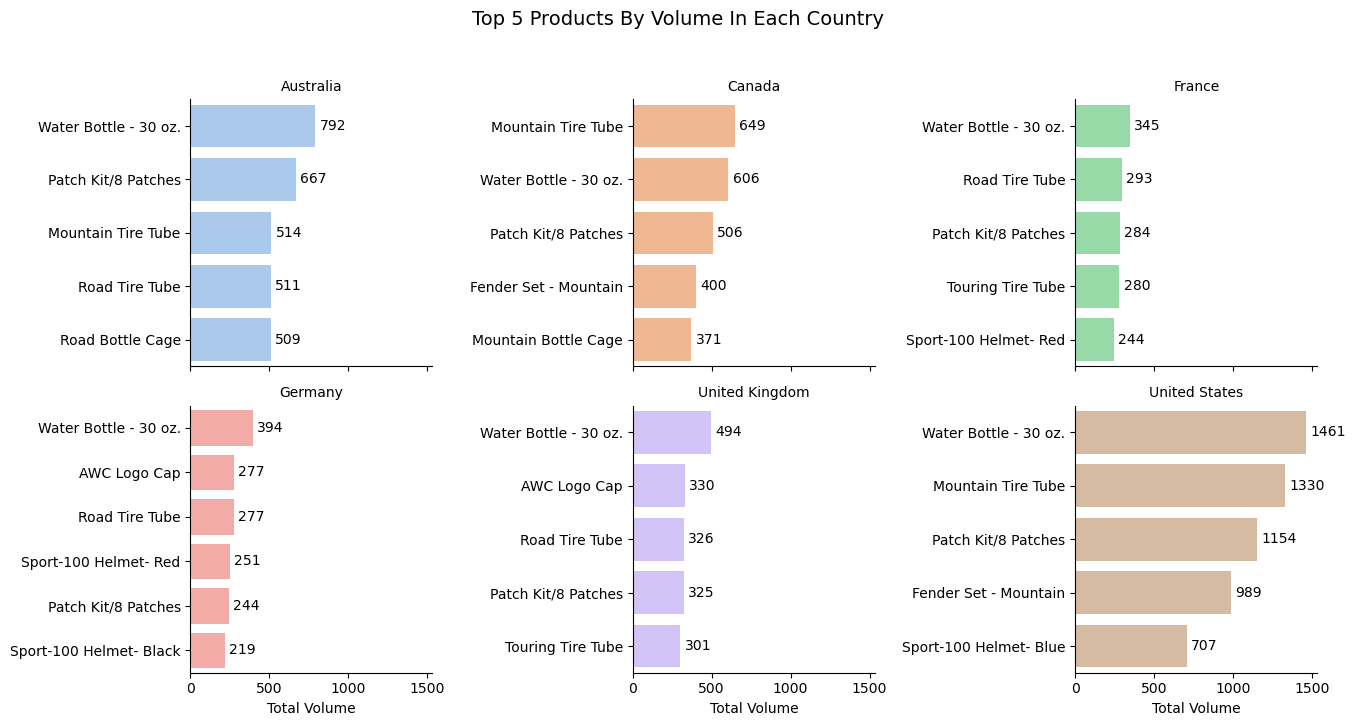

In [695]:
g = sns.catplot(
    data=df_top5,                 #  dataframe
    kind='bar',
    x='Total_Volume',
    y='product_name',
    hue= 'country',
    palette = 'pastel',
    col='country',
    col_wrap=3,                   # 3 charts per row
    sharey=False,                 # each country shows its own products
    height=3.5,
    aspect=1.3,
    legend = False
)

# value labels on each bar
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c,padding = 3)

g.figure.suptitle('Top 5 Products By Volume In Each Country', fontsize=14, y=1.03)
g.set_titles('{col_name}')
g.set_axis_labels('Total Volume','')
plt.tight_layout()
plt.show()
g.figure.savefig('Top 5 Products By Volume In Each Country.png',dpi=300,bbox_inches='tight')

In [668]:
for ax in g.axes.flat:      # ek-ek chart uthao (Australia, phir Canada, ...)
    print(ax.get_title())

Australia
Canada
France
Germany
United Kingdom
United States


####  ADVANCED ANALYSIS: TIME SERIES & MOVING AVERAGES

##### Year-over-Year (YoY) Sales, customer retained and Volume Trends

In [200]:
dffs.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9


In [261]:
# Creating date attritbutes to analysis trends over the period of time.

dffs['year'] = dffs['order_date'].dt.year
dffs['month'] = dffs['order_date'].dt.month
dffs['month_name'] = dffs['order_date'].dt.month_name()
dffs['day_name'] = dffs['order_date'].dt.day_name()
dffs['day'] = dffs['order_date'].dt.day

dates = dffs[['year','month','month_name','day_name','day']]
dates

,year,month,month_name,day_name,day
0,2013.0,3.0,March,Saturday,16.0
1,2013.0,3.0,March,Saturday,16.0
2,2013.0,3.0,March,Saturday,16.0
3,2013.0,3.0,March,Saturday,16.0
4,2013.0,3.0,March,Saturday,16.0
...,...,...,...,...,...
60393,2013.0,3.0,March,Saturday,16.0
60394,2013.0,3.0,March,Saturday,16.0
60395,2013.0,3.0,March,Saturday,16.0
60396,2013.0,3.0,March,Saturday,16.0


In [267]:
rows = dates.shape[0]
columns =  dates.shape[1]

print(f'Total Rows = {rows} and Total Columns = {columns}')

Total Rows = 60398 and Total Columns = 5


In [268]:
dates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        60379 non-null  float64
 1   month       60379 non-null  float64
 2   month_name  60379 non-null  object 
 3   day_name    60379 non-null  object 
 4   day         60379 non-null  float64
dtypes: float64(3), object(2)
memory usage: 2.3+ MB


In [269]:
# changeing datatypes of columns year, month,day

dffs['year'] = dffs['year'].astype('Int64')   ## using capital Int64 as it is pandas nullable interger datatype allows <NA> whereas small int is numpy datatype  which doesnt.
dffs['month'] = dffs['month'].astype('Int64')
dffs['day'] = dffs['day'].astype('Int64')

dffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   60398 non-null  object        
 1   product_key    60398 non-null  int64         
 2   customer_key   60398 non-null  int64         
 3   order_date     60379 non-null  datetime64[ns]
 4   shipping_date  60398 non-null  datetime64[ns]
 5   due_date       60398 non-null  datetime64[ns]
 6   sales_amount   60398 non-null  int64         
 7   quantity       60398 non-null  int64         
 8   price          60398 non-null  int64         
 9   year           60379 non-null  Int64         
 10  month          60379 non-null  Int64         
 11  month_name     60379 non-null  object        
 12  day_name       60379 non-null  object        
 13  day            60379 non-null  Int64         
dtypes: Int64(3), datetime64[ns](3), int64(5), object(3)
memory usage: 6.6+

##### Total Revenue,customer retained and total qty sold by year

In [291]:
joined_dffs_with_df.loc[:6]

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,year,month,month_name,day_name,day,country,gender,marital_status
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,2013,3,March,Saturday,16,Germany,Male,Single
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,2013,3,March,Saturday,16,Germany,Male,Single
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,2013,3,March,Saturday,16,Germany,Male,Single
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,2013,3,March,Saturday,16,Canada,Male,Single
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,2013,3,March,Saturday,16,Canada,Male,Single
5,SO54498,174,4825,2013-03-16,2013-03-23,2013-03-28,22,1,22,2013,3,March,Saturday,16,United States,Female,Single
6,SO54498,277,4825,2013-03-16,2013-03-23,2013-03-28,54,1,54,2013,3,March,Saturday,16,United States,Female,Single


In [312]:
null_count = joined_dffs_with_df.isna().sum()

null_count[null_count > 0]

order_date     19
year           19
month          19
month_name     19
day_name       19
day            19
country       871
gender         33
dtype: int64

In [318]:
joined_dffs_with_df.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,year,month,month_name,day_name,day,country,gender,marital_status
0,SO54496,282,5400,2013-03-16,2013-03-23,2013-03-28,25,1,25,2013,3,March,Saturday,16,Germany,Male,Single
1,SO54496,289,5400,2013-03-16,2013-03-23,2013-03-28,5,1,5,2013,3,March,Saturday,16,Germany,Male,Single
2,SO54496,259,5400,2013-03-16,2013-03-23,2013-03-28,2,1,2,2013,3,March,Saturday,16,Germany,Male,Single
3,SO54497,174,9281,2013-03-16,2013-03-23,2013-03-28,22,1,22,2013,3,March,Saturday,16,Canada,Male,Single
4,SO54497,280,9281,2013-03-16,2013-03-23,2013-03-28,9,1,9,2013,3,March,Saturday,16,Canada,Male,Single


In [363]:
year_wise_revenue_unitsold =joined_dffs_with_df.groupby('year').agg(**
{
'Total Revenue(m)': ('sales_amount',lambda x:x.sum() / 10_00_000),
'Total Qty Sold(units)': ('quantity',lambda q:q.sum())
}
).reset_index()

year_wise_revenue_unitsold['Total Revenue(m)'] = year_wise_revenue_unitsold['Total Revenue(m)'].round(2)
year_wise_revenue_unitsold

,year,Total Revenue(m),Total Qty Sold(units)
0,2010,0.04,14
1,2011,7.08,2216
2,2012,5.84,3397
3,2013,16.34,52807
4,2014,0.05,1970


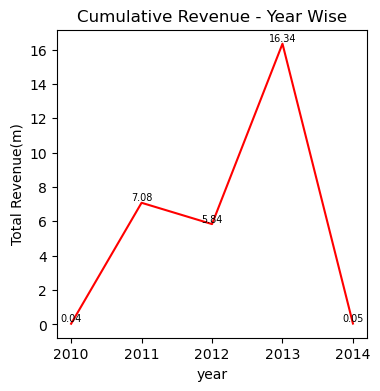

In [689]:
plt.figure(figsize=(4,4))
ax = sns.lineplot(
    data= year_wise_revenue_unitsold,
    x = 'year' , 
    y='Total Revenue(m)',
    markers = 'o',
    color = 'Red',
    errorbar=None
)

for x,y in zip(year_wise_revenue_unitsold['year'],year_wise_revenue_unitsold['Total Revenue(m)']):
    ax.text(x,y,y,fontsize=7,color='Black',ha='center',va='bottom')

plt.title('Cumulative Revenue - Year Wise')
plt.savefig('Cumulative Revenue - Year Wise.png',dpi=300,bbox_inches='tight')

plt.show()

In [457]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]